# Persona Project — Visualization
Standalone visualization for the Persona Project. Loads everything from CSV/JSON files in `data/` — does not depend on running the simulation notebook.

**Required files:**
- `data/metrics_all.csv` (from main notebook)
- `results/results_{model}_k{k}.csv` (one per model × k)
- `data/question_bank.json` (scale info, auto-saved by main notebook Part 8)
- `data/20172018_data.sav` (raw JGSS data, needed for Plot D real distributions)

## Load data

In [ ]:
import glob, re, os, json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import pyreadstat

# CJK-capable font so Japanese question text renders without warnings
_jp_font_prefs = ['Hiragino Sans', 'Hiragino Kaku Gothic ProN', 'IPAexGothic',
                  'Noto Sans CJK JP', 'Yu Gothic', 'Meiryo']
_available = {f.name for f in fm.fontManager.ttflist}
_jp_font = next((f for f in _jp_font_prefs if f in _available), None)
if _jp_font:
    plt.rcParams['font.family'] = _jp_font
else:
    print("Warning: no Japanese font found — CJK characters in plot titles may not render.")

MODEL_COLORS = {
    'gemini':     '#4A90D9',
    'chatgpt':    '#27AE60',
    'claude':     '#E67E22',
    'llama_base_8b': "#FF0D00",   # untuned Llama-3.1-8B (lighter red — same family as Swallow)
    'llama_tuned_8b':      "#6B1515",   # Llama-Swallow (Japanese-tuned)
    'real':       '#555555',
}
_MODEL_ORDER = ['gemini', 'chatgpt', 'claude', 'llama_base_8b', 'llama_tuned_8b']

# 1. Metrics
metrics_viz = pd.read_csv('results/metrics_all.csv')
metrics_viz['jsd'] = pd.to_numeric(metrics_viz['jsd'], errors='coerce')
metrics_viz['valid_rate'] = metrics_viz['valid_answers'] / metrics_viz['total_personas']

# 2. Per-model results (auto-discover)
results_viz = {}
for path in sorted(glob.glob('results/results_*_k*.csv')):
    m = re.search(r'results_(.+)_k(\d+)\.csv$', os.path.basename(path))
    if m:
        model, k = m.group(1), int(m.group(2))
        results_viz[(model, k)] = pd.read_csv(path, index_col=0)

# 3. Question bank (for Plot D scales)
with open('results/question_bank.json', encoding='utf-8') as _f:
    question_bank = json.load(_f)

# 4. Raw JGSS data (only needed for Plot D real distributions)
#    Loading may take a few seconds — comment out if you only want Plots A/B/C
df, _meta = pyreadstat.read_sav('data/20172018_data_jap.sav')
for col in df.columns:
    df[col] = df[col].replace({9: np.nan, 99: np.nan, 999: np.nan})

all_models = sorted(
    metrics_viz['model'].unique(),
    key=lambda x: _MODEL_ORDER.index(x) if x in _MODEL_ORDER else 99
)
all_k = sorted(metrics_viz['persona_k'].unique())
all_q = sorted(metrics_viz['question_var'].unique())

print(f"Models  : {all_models}")
print(f"k values: {all_k}")
print(f"Questions: {len(all_q)} active in metrics, {len(question_bank)} in bank")
print(f"Results files: {sorted(results_viz.keys())}")


Models  : ['chatgpt', 'llama_tuned_8b']
k values: [np.int64(2), np.int64(8), np.int64(16)]
Questions: 19 active in metrics, 19 in bank
Results files: [('chatgpt', 2), ('chatgpt', 8), ('chatgpt', 16), ('llama_tuned_8b', 2), ('llama_tuned_8b', 8), ('llama_tuned_8b', 16)]


## Plot A — All-data overview

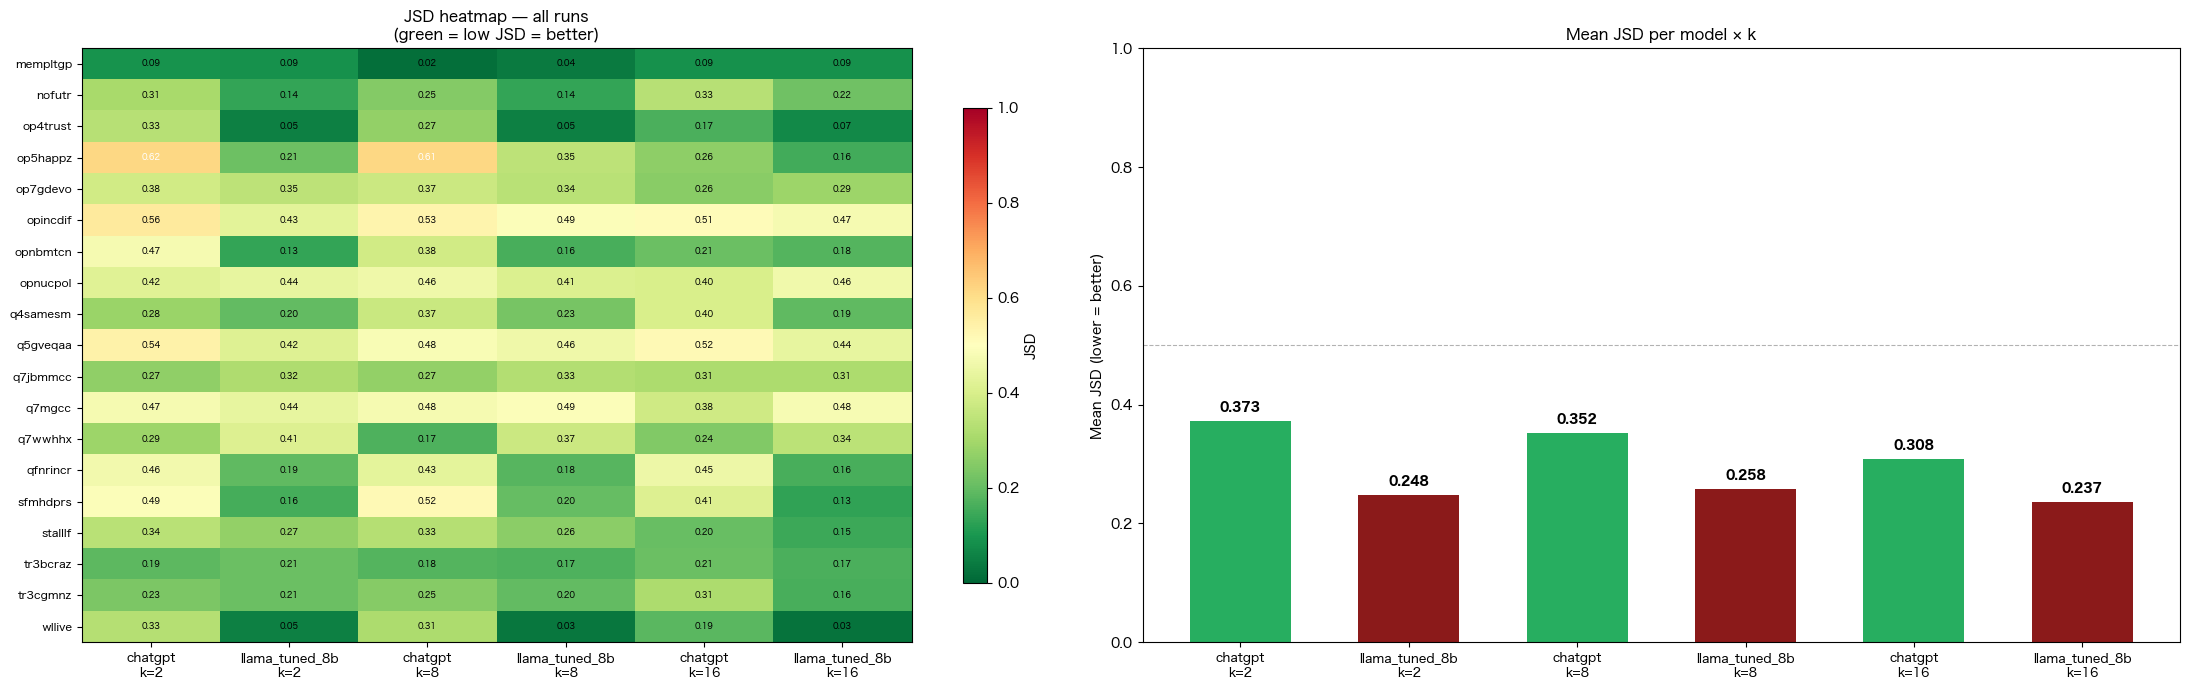

Saved: data/viz_overview.png


In [17]:
# ── Plot A: all-data overview ─────────────────────────────────────────────────
# Left : JSD heatmap  (questions × model_k combos)
# Right: mean JSD per (model, k) — key result bar

combos = [
    (m, k) for k in all_k for m in all_models
    if not metrics_viz[(metrics_viz['model'] == m) & (metrics_viz['persona_k'] == k)].empty
]
col_labels = [f"{m}\nk={k}" for m, k in combos]

heat_rows = {}
for m, k in combos:
    sub = metrics_viz[(metrics_viz['model'] == m) & (metrics_viz['persona_k'] == k)]
    heat_rows[f"{m}\nk={k}"] = sub.set_index('question_var')['jsd']
heat_df = pd.DataFrame(heat_rows, index=all_q)

fig, axes = plt.subplots(1, 2, figsize=(max(12, 3 * len(combos) + 4), 7))

# Heatmap
ax = axes[0]
im = ax.imshow(heat_df.values, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(combos)));     ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(all_q)));      ax.set_yticklabels(all_q, fontsize=8)
ax.set_title('JSD heatmap — all runs\n(green = low JSD = better)', fontsize=11)
plt.colorbar(im, ax=ax, label='JSD', shrink=0.8)
for i in range(len(all_q)):
    for j in range(len(combos)):
        v = heat_df.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if v > 0.6 else 'black')

# Mean-JSD bar chart
summary = (metrics_viz.groupby(['model', 'persona_k'])['jsd']
           .mean().reset_index())
summary.sort_values(['persona_k', 'model'], inplace=True)
labels  = [f"{r.model}\nk={r.persona_k}" for _, r in summary.iterrows()]
colors  = [MODEL_COLORS.get(r.model, '#999') for _, r in summary.iterrows()]
ax2 = axes[1]
bars = ax2.bar(range(len(summary)), summary['jsd'], color=colors, width=0.6)
ax2.set_xticks(range(len(summary))); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylim(0, 1); ax2.set_ylabel('Mean JSD (lower = better)')
ax2.set_title('Mean JSD per model × k', fontsize=11)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, summary['jsd']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/viz_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/viz_overview.png")


## Plot B — JSD by question, split by k

In [ ]:
# ── Plot B: JSD by question — one subplot per k ───────────────────────────────
n_k   = len(all_k)
x     = np.arange(len(all_q))

fig, axes = plt.subplots(1, n_k, figsize=(7 * n_k, 5), sharey=True)
if n_k == 1:
    axes = [axes]

for ax, k in zip(axes, all_k):
    sub_k       = metrics_viz[metrics_viz['persona_k'] == k]
    models_at_k = [m for m in all_models if m in sub_k['model'].unique()]
    bw          = 0.8 / max(len(models_at_k), 1)

    for i, m in enumerate(models_at_k):
        jsd_vals = (sub_k[sub_k['model'] == m]
                    .set_index('question_var')['jsd']
                    .reindex(all_q))
        offset = (i - len(models_at_k) / 2 + 0.5) * bw
        ax.bar(x + offset, jsd_vals, width=bw,
               label=m, color=MODEL_COLORS.get(m, '#999'), alpha=0.88)

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(f'k = {k}', fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(all_q, rotation=50, ha='right', fontsize=7)
    ax.set_ylim(0, 1)
    if k == all_k[0]:
        ax.set_ylabel('JSD (lower = better)')
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('JSD by question — model comparison split by k', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/viz_jsd_per_k.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/viz_jsd_per_k.png")


## Plot C — Valid answer rate, split by k

In [ ]:
# ── Plot C: valid answer rate — one subplot per k ─────────────────────────────
fig, axes = plt.subplots(1, n_k, figsize=(7 * n_k, 4), sharey=True)
if n_k == 1:
    axes = [axes]

for ax, k in zip(axes, all_k):
    sub_k       = metrics_viz[metrics_viz['persona_k'] == k]
    models_at_k = [m for m in all_models if m in sub_k['model'].unique()]
    bw          = 0.8 / max(len(models_at_k), 1)

    for i, m in enumerate(models_at_k):
        vr_vals = (sub_k[sub_k['model'] == m]
                   .set_index('question_var')['valid_rate']
                   .reindex(all_q))
        offset = (i - len(models_at_k) / 2 + 0.5) * bw
        ax.bar(x + offset, vr_vals, width=bw,
               label=m, color=MODEL_COLORS.get(m, '#999'), alpha=0.88)

    ax.set_title(f'k = {k}', fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(all_q, rotation=50, ha='right', fontsize=7)
    ax.set_ylim(0, 1.05)
    if k == all_k[0]:
        ax.set_ylabel('Valid answer rate')
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('Valid answer rate — model comparison split by k', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/viz_valid_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/viz_valid_rate.png")


## Plot D — Distribution comparison

In [ ]:
# ── Plot D: distribution comparison — real vs models, split by k ──────────────
# Requires df (Part 4) and question_bank (Part 2) to be in memory.
# VIZ_QUESTIONS: which questions to plot. Default = first 6 in question_bank.
VIZ_QUESTIONS = list(question_bank.keys())[:6]   # edit as needed

for qvar in VIZ_QUESTIONS:
    scale_min = question_bank[qvar]['scale_min']
    scale_max = question_bank[qvar]['scale_max']
    vals      = list(range(scale_min, scale_max + 1))
    n_cols    = 1 + len(all_k)       # real + one per k

    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), sharey=True)

    # Real distribution
    real_dist = (df[qvar].dropna().astype(int)
                 .value_counts(normalize=True)
                 .reindex(vals, fill_value=0))
    axes[0].bar(vals, real_dist.values, color=MODEL_COLORS['real'], alpha=0.85)
    axes[0].set_title('Real (JGSS)', fontsize=10)
    axes[0].set_xticks(vals); axes[0].set_xlabel('Answer')
    axes[0].set_ylabel('Proportion')

    # One subplot per k
    for col_idx, k in enumerate(all_k, start=1):
        ax = axes[col_idx]
        models_here = [m for (m, kk) in results_viz if kk == k
                       and qvar in results_viz[(m, kk)].columns]
        bw = 0.8 / max(len(models_here), 1)
        x_arr = np.array(vals, dtype=float)

        for j, m in enumerate(models_here):
            sim_dist = (results_viz[(m, k)][qvar].dropna().astype(int)
                        .value_counts(normalize=True)
                        .reindex(vals, fill_value=0))
            offset = (j - len(models_here) / 2 + 0.5) * bw
            ax.bar(x_arr + offset, sim_dist.values, width=bw,
                   label=m, color=MODEL_COLORS.get(m, '#999'), alpha=0.85)

        ax.set_title(f'k = {k}', fontsize=10)
        ax.set_xticks(vals); ax.set_xlabel('Answer')
        ax.legend(fontsize=7)

    short_q = question_bank[qvar]['question'][:70]
    fig.suptitle(f'{qvar}: {short_q}', fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()
